<a href="https://www.kaggle.com/code/durandekamga/llm-from-scratch?scriptVersionId=323498241" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import time

In [3]:
BLOCK_SIZE     = 256      
BATCH_SIZE     = 128     
MAX_ITERS      = 5000
EVAL_INTERVAL  = 300
EVAL_ITERS     = 30
LEARNING_RATE  = 3e-4
embeding_size  = 384      
heads          = 6        
num_layers     = 6        
forward_exp    = 4
dropout        = 0.1
MAX_CHARS = 20_000_000
device         = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device   : {device}")
print(f"Nb GPUs  : {torch.cuda.device_count()}")

Device   : cuda
Nb GPUs  : 2


In [4]:
print("Chargement wikipedia...")
ds = load_dataset("wikimedia/wikipedia", "20231101.fr", split="train")
full_text = ""
for article in ds["text"]:
    full_text += article + "\n"
    if len(full_text) >= MAX_CHARS:
        break
full_text = full_text[:MAX_CHARS]
print(f"Texte utilise : {len(full_text):,} caracteres")

Chargement wikipedia...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

20231101.fr/train-00000-of-00017.parquet:   0%|          | 0.00/769M [00:00<?, ?B/s]

20231101.fr/train-00001-of-00017.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

...

20231101.fr/train-00015-of-00017.parquet:   0%|          | 0.00/186M [00:00<?, ?B/s]

20231101.fr/train-00016-of-00017.parquet:   0%|          | 0.00/186M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2564646 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Texte utilise : 20,000,000 caracteres


In [5]:
full_text[:50]

'Antoine Meillet, né le  à Moulins (Allier) et mort'

In [6]:
chars      = sorted(set(full_text))
vocab_size = len(chars)
stoi       = {ch: i  for i, ch in enumerate(chars)}   
itos       = {i:  ch for i, ch in enumerate(chars)} 
encode     = lambda s: [stoi[c] for c in s]
decode     = lambda l: "".join([itos[i] for i in l])

In [7]:
print(f"Vocabulaire : {vocab_size} caracteres uniques")
print(f"texte hello     : {chars[:20]}")

Vocabulaire : 1215 caracteres uniques
texte hello     : ['\t', '\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1']


# Encoder le texte

90% de données pour le train et 10% pour la validation (s'assurer que le modèle génère bien et ne récite pas juste)

In [8]:
data = torch.tensor(encode(full_text), dtype=torch.long)
n    = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f"Train : {len(train_data):,} tokens | Val : {len(val_data):,} tokens")

Train : 18,000,000 tokens | Val : 2,000,000 tokens


In [9]:
class TextDataset(Dataset):
    """
    x = caracteres[i : i+BLOCK_SIZE]
    y = caracteres[i+1 : i+BLOCK_SIZE+1]
    Le modele apprend a predire le caractere suivant a chaque position.
    """
    def __init__(self, data):
        self.data = data
 
    def __len__(self):
        return len(self.data) - BLOCK_SIZE
 
    def __getitem__(self, idx):
        x = self.data[idx     : idx + BLOCK_SIZE]
        y = self.data[idx + 1 : idx + BLOCK_SIZE + 1]
        return x, y


train_loader = DataLoader(TextDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(TextDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Batches train : {len(train_loader):,}")

Batches train : 140,623


In [10]:
class SelfAttention(nn.Module):
    def __init__(self, embeding_size, heads):
        super().__init__()
        self.embeding_size = embeding_size
        self.heads         = heads
        self.head_dim      = embeding_size // heads
        assert self.head_dim * heads == embeding_size
        self.values  = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys    = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out  = nn.Linear(heads * self.head_dim, embeding_size)
 
    def forward(self, values, keys, query, mask):
        N                             = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
 
        values  = values.reshape(N, value_len, self.heads, self.head_dim)
        keys    = keys.reshape(N, key_len,     self.heads, self.head_dim)
        queries = query.reshape(N, query_len,  self.heads, self.head_dim)
 
        values  = self.values(values)
        keys    = self.keys(keys)
        queries = self.queries(queries)
 
        queries = queries.permute(0, 2, 1, 3)
        keys    = keys.permute(0, 2, 1, 3)
        values  = values.permute(0, 2, 1, 3)
 
        energy = queries @ keys.transpose(-2, -1)
 
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embeding_size ** 0.5), dim=3)
        out       = attention @ values
        out       = out.permute(0, 2, 1, 3).reshape(N, query_len, self.heads * self.head_dim)
        out       = self.fc_out(out)
        return out

class DecoderBlock(nn.Module):
    """
    Bloc decoder-only :
    - Masked Self-Attention  : chaque caractere regarde les precedents
    - FFN                    : traitement independant par position
    Plus de cross-attention, plus besoin de enc_out.
    """
    def __init__(self, embeding_size, heads, forward_expansion, dropout):
        super().__init__()
        self.attention = SelfAttention(embeding_size, heads)
        self.norm1     = nn.LayerNorm(embeding_size)
        self.norm2     = nn.LayerNorm(embeding_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embeding_size, forward_expansion * embeding_size),
            nn.ReLU(),
            nn.Linear(forward_expansion * embeding_size, embeding_size),
            nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x, mask):
        # 1. Masked self-attention + residuel
        attention = self.attention(x, x, x, mask)
        x         = self.dropout(self.norm1(attention + x))
 
        # 2. FFN + residuel
        forward = self.feed_forward(x)
        out     = self.dropout(self.norm2(forward + x))
        return out

class DecoderOnlyLM(nn.Module):
    """
    LLM decoder-only :
    Embedding -> N blocs DecoderBlock -> Linear(vocab_size)
    Genere un caractere a la fois de facon autoregressives.
    """
    def __init__(self, vocab_size, embeding_size, num_layers, heads,
                 forward_expansion, dropout, max_length):
        super().__init__()
        self.word_embedding     = nn.Embedding(vocab_size, embeding_size)
        self.position_embedding = nn.Embedding(max_length, embeding_size)
        self.layers = nn.ModuleList([
            DecoderBlock(embeding_size, heads, forward_expansion, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out  = nn.Linear(embeding_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
 
        # masque causal partage (triangle inferieur de 1s)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(max_length, max_length))
        )
 
    def forward(self, x, targets=None):
        N, T  = x.shape
        pos   = torch.arange(0, T, device=x.device).expand(N, T)
 
        # Embedding token + position
        x     = self.dropout(self.word_embedding(x) + self.position_embedding(pos))
 
        # Masque causal adapte a la longueur courante
        mask  = self.causal_mask[:T, :T]
 
        # N blocs decoder
        for layer in self.layers:
            x = layer(x, mask)
 
        # Projection sur le vocabulaire
        logits = self.fc_out(x)   # (N, T, vocab_size)
 
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )
 
        return logits, loss
 
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8):
        """
        Generation caractere par caractere.
        temperature : 0.5 = plus deterministe / 1.5 = plus creatif
        """
        for _ in range(max_new_tokens):
            idx_cond  = idx[:, -BLOCK_SIZE:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :] / temperature
            probs     = F.softmax(logits, dim=-1)
            idx_nxt   = torch.multinomial(probs, num_samples=1)
            idx       = torch.cat([idx, idx_nxt], dim=1)
        return idx

In [11]:
model = DecoderOnlyLM(
    vocab_size        = vocab_size,
    embeding_size     = embeding_size,
    num_layers        = num_layers,
    heads             = heads,
    forward_expansion = forward_exp,
    dropout           = dropout,
    max_length        = BLOCK_SIZE,
)
 
if torch.cuda.device_count() > 1:
    print(f"Multi-GPU : {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
 
model     = model.to(device)
total     = sum(p.numel() for p in model.parameters())
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_ITERS, eta_min=LEARNING_RATE/10)
print(f"Parametres : {total/1e6:.2f}M")

Multi-GPU : 2 GPUs
Parametres : 9.09M


In [12]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split, loader in [("train", train_loader), ("val", val_loader)]:
        losses = []
        for i, (x, y) in enumerate(loader):
            if i >= EVAL_ITERS:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            losses.append(loss.mean().item())
        out[split] = sum(losses) / len(losses)
    model.train()
    return out

In [13]:
train_losses = []
val_losses   = []
steps_log    = []

print("\nEntrainement...")
best_val   = float("inf")
train_iter = iter(train_loader)
t0         = time.time()

for step in range(MAX_ITERS):
    try:
        x, y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y = next(train_iter)

    x, y    = x.to(device), y.to(device)
    _, loss = model(x, y)
    loss    = loss.mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if step % EVAL_INTERVAL == 0 or step == MAX_ITERS - 1:
        losses = estimate_loss()

        # stocker pour le plot
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps_log.append(step)

        print(f"step {step:4d} | train {losses['train']:.4f} | val {losses['val']:.4f} | {time.time()-t0:.0f}s")
        if losses["val"] < best_val:
            best_val  = losses["val"]
            raw_model = model.module if isinstance(model, nn.DataParallel) else model
            torch.save(raw_model.state_dict(), "best_model.pt")
            print(f"  -> sauvegarde (val={best_val:.4f})")



Entrainement...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


step    0 | train 5.6675 | val 5.7011 | 13s
  -> sauvegarde (val=5.7011)
step  300 | train 2.4900 | val 2.4724 | 142s
  -> sauvegarde (val=2.4724)
step  600 | train 2.4245 | val 2.4086 | 282s
  -> sauvegarde (val=2.4086)
step  900 | train 2.1750 | val 2.1644 | 427s
  -> sauvegarde (val=2.1644)
step 1200 | train 2.0243 | val 2.0220 | 573s
  -> sauvegarde (val=2.0220)
step 1500 | train 1.9151 | val 1.9164 | 719s
  -> sauvegarde (val=1.9164)
step 1800 | train 1.8277 | val 1.8421 | 865s
  -> sauvegarde (val=1.8421)
step 2100 | train 1.7703 | val 1.7832 | 1012s
  -> sauvegarde (val=1.7832)
step 2400 | train 1.7228 | val 1.7383 | 1157s
  -> sauvegarde (val=1.7383)
step 2700 | train 1.6943 | val 1.6998 | 1304s
  -> sauvegarde (val=1.6998)
step 3000 | train 1.6616 | val 1.6701 | 1450s
  -> sauvegarde (val=1.6701)
step 3300 | train 1.6438 | val 1.6572 | 1596s
  -> sauvegarde (val=1.6572)
step 3600 | train 1.6260 | val 1.6359 | 1742s
  -> sauvegarde (val=1.6359)
step 3900 | train 1.6163 | val 1.

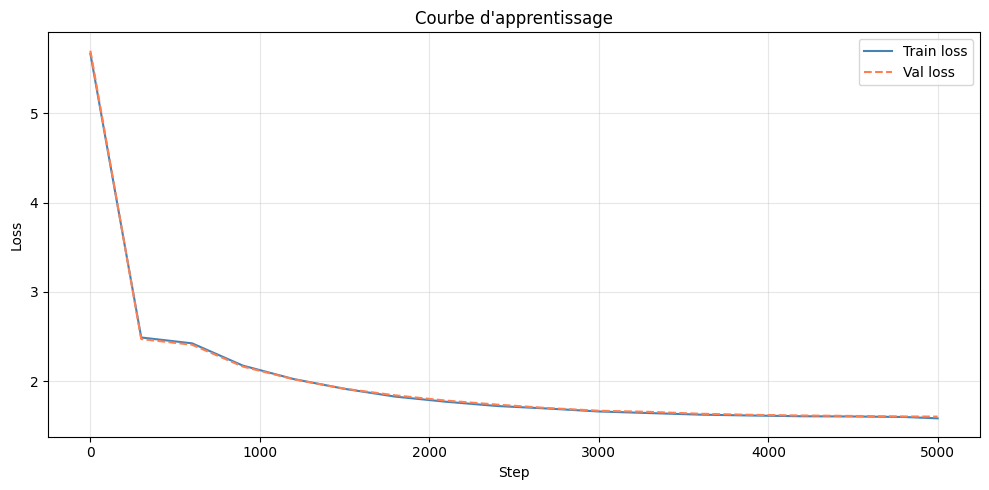

Courbe sauvegardee : loss_curve.png


In [14]:
# APRES la boucle : plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(steps_log, train_losses, label="Train loss", color="steelblue")
plt.plot(steps_log, val_losses,   label="Val loss",   color="coral", linestyle="--")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("Courbe sauvegardee : loss_curve.png")

In [15]:
raw_model = model.module if isinstance(model, nn.DataParallel) else model
raw_model.eval()
 
prompt = "Mon nom est durande"
ctx    = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
 
with torch.no_grad():
    output = raw_model.generate(ctx, max_new_tokens=300, temperature=0.8)
 
print("\n" + "="*50)
print(decode(output[0].tolist()))
print("="*50)


Mon nom est durande la compagne.

La suite de la proport de Marivie l'origine de l’étable de la Réviduité, des et prions du Premier cantres  à des restes dans les proposités de la plupart et le vie est un premier de la chaque du Nivert-Les recherches de général de stituge. La représent de la production d'Il animande e
